# 02 - Retention EDA
Exploratory analysis for retention and cohort behaviors.

### Business Question
What does churn look like?

Our goal is to understand the shape of member retention at a business level.

This notebook explores:

- How many members are active vs cancelled
- Whether churn varies by club tier
- Whether churn varies by acquisition source
- Whether churn varies by geography
- How long members typically remain active
- Whether churn appears concentrated in certain lifecycle windows


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

RAW_DIR = Path("../data/raw")
DIM_DIR = Path("../data/dim")

raw_members = pd.read_csv(RAW_DIR / "raw_members.csv")
raw_membership_events = pd.read_csv(RAW_DIR / "raw_membership_events.csv")
raw_orders = pd.read_csv(RAW_DIR / "raw_orders.csv")
raw_order_items = pd.read_csv(RAW_DIR / "raw_order_items.csv")
raw_tasting_room_visits = pd.read_csv(RAW_DIR / "raw_tasting_room_visits.csv")
raw_event_attendance = pd.read_csv(RAW_DIR / "raw_event_attendance.csv")
raw_email_events = pd.read_csv(RAW_DIR / "raw_email_events.csv")

dim_club_tiers = pd.read_csv(DIM_DIR / "dim_club_tiers.csv")
dim_acquisition_sources = pd.read_csv(DIM_DIR / "dim_acquisition_sources.csv")

In [2]:
# Parse Dates

raw_members["join_date"] = pd.to_datetime(raw_members["join_date"], errors="coerce")
raw_members["birth_date"] = pd.to_datetime(raw_members["birth_date"], errors="coerce")

raw_membership_events["event_date"] = pd.to_datetime(raw_membership_events["event_date"], errors="coerce")
raw_orders["order_date"] = pd.to_datetime(raw_orders["order_date"], errors="coerce")
raw_tasting_room_visits["visit_date"] = pd.to_datetime(raw_tasting_room_visits["visit_date"], errors="coerce")
raw_event_attendance["event_date"] = pd.to_datetime(raw_event_attendance["event_date"], errors="coerce")
raw_email_events["send_date"] = pd.to_datetime(raw_email_events["send_date"], errors="coerce")

In [3]:
# Set analysis cut off date
analysis_date = pd.to_datetime("2025-12-31")

In [5]:
# Active and Cancelle Members

member_status_summary = (
    raw_members.groupby('member_status').agg(members=('member_id', 'nunique')).reset_index()
)

member_status_summary['member_share'] = (
    member_status_summary['members'] / member_status_summary['members'].sum()
)

member_status_summary

,member_status,members,member_share
0,active,3749,0.892619
1,cancelled,451,0.107381


In [6]:
# Churn by club tier
# Which club has the highest churn rate?

churn_by_tier = (
    raw_members.groupby('current_club_tier').agg(members=('member_id', 'nunique'),
    cancelled_members=('member_status', lambda x:(x == 'cancelled').sum())
    ).reset_index()
)

churn_by_tier['active_members'] = (
    churn_by_tier['members'] - churn_by_tier['cancelled_members']
)

churn_by_tier['churn_rate'] = (
    churn_by_tier['cancelled_members'] / churn_by_tier['members']
)

churn_by_tier = churn_by_tier.sort_values('churn_rate', ascending=False)

churn_by_tier

,current_club_tier,members,cancelled_members,active_members,churn_rate
0,12 bottle,364,45,319,0.123626
1,2 bottle,1657,204,1453,0.123114
2,4 bottle,1376,146,1230,0.106105
3,6 bottle,803,56,747,0.069738


In [7]:
churn_by_tier_display = churn_by_tier.copy()

churn_by_tier_display['churn_rate'] = (
    churn_by_tier_display['churn_rate'] * 100
).round(1).astype(str) + '%'

churn_by_tier_display

,current_club_tier,members,cancelled_members,active_members,churn_rate
0,12 bottle,364,45,319,12.4%
1,2 bottle,1657,204,1453,12.3%
2,4 bottle,1376,146,1230,10.6%
3,6 bottle,803,56,747,7.0%


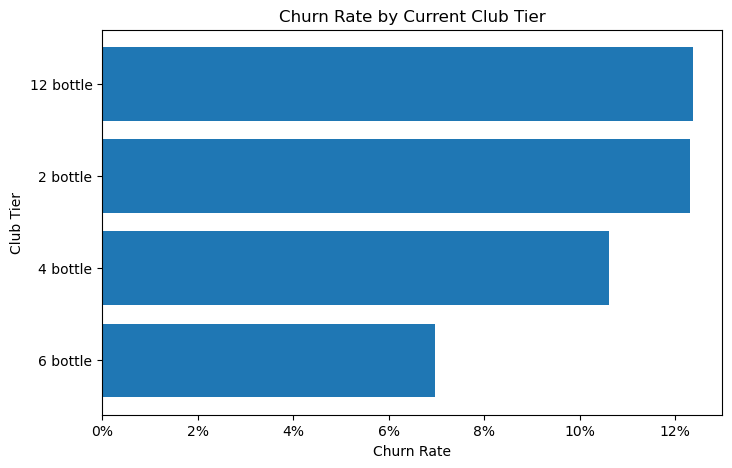

In [8]:
# Create bar chart of Membership Tier Churn Rate

import matplotlib.pyplot as plt

plot_data = churn_by_tier.sort_values('churn_rate', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_data['current_club_tier'], plot_data['churn_rate'])
plt.xlabel('Churn Rate')
plt.ylabel('Club Tier')
plt.title("Churn Rate by Current Club Tier")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.show()

### Churn by Club Tier 

Cancellation rates vary by club tier.
The 12-bottle and 2-bottle tiers have the highest churn rate at 12.4% and 12.3%.

The 2-bottle tier may include more casual or lower-commitment members who are easier to lose. While the 12-bottle tier probably represents a lack of value or relationship depth to rationalize the the larger shipment sizes and/or higher cost.

The 6-bottle tier seems to be the strongest retention tier. This may represent a 'premium sweet spot', where members are committed enough to have strong purchase intent while not feeling overburdened by the shipment sizes or cost.

In [13]:
# Churn by Acqusition Source

# Question:
# Which acquisition sources produce members who stay,
# and which sources produce members who are more likely to cancel?

churn_by_source = (
    raw_members
    .groupby("acquisition_source")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("member_status", lambda x: (x == "cancelled").sum())
    )
    .reset_index()
)

churn_by_source["active_members"] = (
    churn_by_source["members"] - churn_by_source["cancelled_members"]
)


churn_by_source['churn_rate'] = (
    churn_by_source['cancelled_members'] / churn_by_source['members']
)

churn_bysouce = churn_by_source.sort_values('churn_rate', ascending=False)

churn_by_source

,acquisition_source,members,cancelled_members,active_members,churn_rate
0,concierge,259,15,244,0.057915
1,event,298,45,253,0.151007
2,paid_social,297,66,231,0.222222
3,referral,430,22,408,0.051163
4,repeat_tasting_room_visit,190,2,188,0.010526
5,tasting_room,1494,99,1395,0.066265
6,website,1010,166,844,0.164356
7,wine_club_gift,222,36,186,0.162162


### Churn by Acquisition Source Findings

Cancellation rate varies sharply by acquisition source. 

Members who joined through paid-social have the highest churn while those who joined from repeat tasting room visits have the lowest. This suggests that retention is strongly connected to the context to which someone joins. Members who join through high-relationship channels appear to stay longer than those who enter through lower-context channels, like digital or a gift.

Members who join outside of the tasting room may need stronger on-boarding, expectation-setting, and early relationship-building after signup.

Something to consider: 
Should the winery focus more on acquiring high-intent members, or should it improve their onboarding for lower-context acquisition channels?

In [15]:
# Churn by Signup Channel

# Question:
# Does the way a member signs up influence retention risk?

churn_by_signup_channel = (
    raw_members.groupby('signup_channel').agg(
        members=('member_id', 'nunique'),
        cancelled_members=('member_status', lambda x:(x == 'cancelled').sum())
    ).reset_index()
)

churn_by_signup_channel['active_members'] = (
    churn_by_signup_channel['members'] - churn_by_signup_channel['cancelled_members']
)

churn_by_signup_channel['churn_rate'] = (
    churn_by_signup_channel['cancelled_members'] / churn_by_signup_channel['members']
)

churn_by_signup_channel = churn_by_signup_channel.sort_values(
    'churn_rate',
    ascending=False
)

churn_by_signup_channel

,signup_channel,members,cancelled_members,active_members,churn_rate
3,online,1529,268,1261,0.175278
1,event_signup,298,45,253,0.151007
2,in_person,1684,101,1583,0.059976
4,phone,259,15,244,0.057915
0,email,430,22,408,0.051163


In [16]:
churn_by_signup_channel_display = churn_by_signup_channel.copy()

churn_by_signup_channel_display['churn_rate'] = (
    churn_by_signup_channel_display['churn_rate'] * 100
).round(1).astype(str) + '%'

churn_by_signup_channel_display

,signup_channel,members,cancelled_members,active_members,churn_rate
3,online,1529,268,1261,17.5%
1,event_signup,298,45,253,15.1%
2,in_person,1684,101,1583,6.0%
4,phone,259,15,244,5.8%
0,email,430,22,408,5.1%


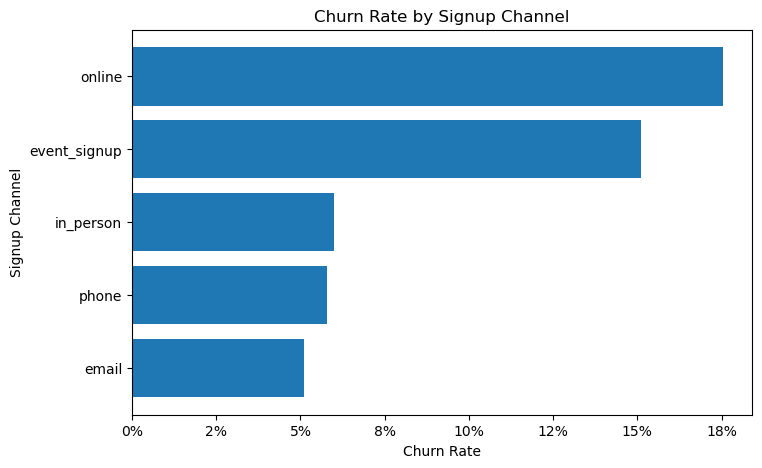

In [17]:
plot_data = churn_by_signup_channel.sort_values("churn_rate", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_data["signup_channel"], plot_data["churn_rate"])
plt.xlabel("Churn Rate")
plt.ylabel("Signup Channel")
plt.title("Churn Rate by Signup Channel")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.show()

### Churn by Signup Channel Findings

Churn varies meaningfully by signup channel. Members who joined online have the highest cancelation rate at 17.5%, followed by event signups at 15.1%.

This suggests that the signup experience may be an important part of retention. Online and event signups may create less relationship-depth or impulse-driven enrollment. In-person and phone signups likely involve more human interactions, which may help members better understand shipment cadence, cost, benefits, and wine prefernces before joining.

Email has the lowest churn at 5.1%, which may suggest warmer audience behavior rather than cold acquistion. 

In [18]:
# Churn by State/ Geography

# Question:
# Does chur vary by member geography, and are out-of-state members more likely to cancel than local/regional members?

churn_by_state = (
    raw_members.groupby('state').agg(
        members=('member_id', 'nunique'),
        cancelled_members=('member_status', lambda x:(x == 'cancelled').sum())
    ).reset_index()
)

churn_by_state["active_members"] = (
    churn_by_state["members"] - churn_by_state["cancelled_members"]
)

churn_by_state["churn_rate"] = (
    churn_by_state["cancelled_members"] / churn_by_state["members"]
)

churn_by_state = churn_by_state.sort_values("churn_rate", ascending=False)

churn_by_state

,state,members,cancelled_members,active_members,churn_rate
15,PA,66,13,53,0.196970
18,VA,74,13,61,0.175676
12,OH,47,8,39,0.170213
5,IL,132,22,110,0.166667
3,FL,285,47,238,0.164912
6,MA,96,15,81,0.156250
9,NJ,79,12,67,0.151899
8,NC,107,16,91,0.149533
11,NY,243,36,207,0.148148
17,TX,351,51,300,0.145299


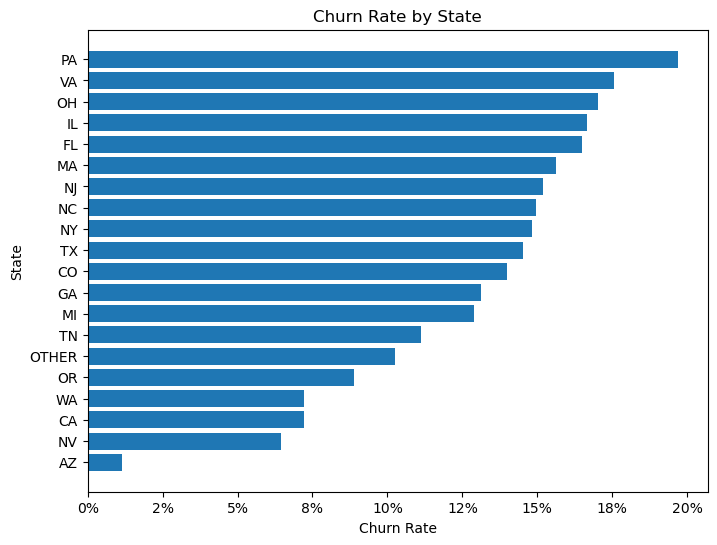

In [20]:
plot_data = churn_by_state.sort_values("churn_rate", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_data["state"], plot_data["churn_rate"])
plt.xlabel("Churn Rate")
plt.ylabel("State")
plt.title("Churn Rate by State")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.show()

In [21]:
# California vs Out-of-State

raw_members_geo = raw_members.copy()

raw_members_geo["geo_segment"] = np.where(
    raw_members_geo["state"] == "CA",
    "California",
    "Out of State"
)

churn_by_geo_segment = (
    raw_members_geo
    .assign(cancelled_flag=raw_members_geo["member_status"].eq("cancelled").astype(int))
    .groupby("geo_segment")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("cancelled_flag", "sum")
    )
    .reset_index()
)

churn_by_geo_segment["active_members"] = (
    churn_by_geo_segment["members"] - churn_by_geo_segment["cancelled_members"]
)

churn_by_geo_segment["churn_rate"] = (
    churn_by_geo_segment["cancelled_members"] / churn_by_geo_segment["members"]
)

churn_by_geo_segment = churn_by_geo_segment.sort_values(
    "churn_rate",
    ascending=False
)

churn_by_geo_segment

,geo_segment,members,cancelled_members,active_members,churn_rate
1,Out of State,2839,353,2486,0.124340
0,California,1361,98,1263,0.072006


### Churn by State/ Geography Findings

State-level churn shows that retention risk is not evenly distributed across geography.

Several East Coast and non-West Coast states show higher churn rates, including Pennsylvania at 19.7%, Virginia at 17.6%, Illinois at 16.7%, Florida at 16.5%, Massachusetts at 15.6%, New Jersey at 15.2%, New York at 14.8%, and Texas at 14.5%.

California has a lower churn rate at 7.2%, and nearby western states such as Nevada, Washington, Oregon, and Arizona generally show lower churn than many farther out-of-state markets.

This suggests that distance from the winery may matter. Members who are farther away may have fewer opportunities to visit, attend events, pick up shipments, or build an ongoing relationship with the brand. Their experience may depend more heavily on shipment value, email communication, and whether each release feels worth the cost.

In [22]:
# Churn Timing by Month, Quarter, and Club Release

# Question:
# Are cancellations concentrated around certain months, quarters, or club release windows?

cancellations = (
    raw_membership_events
    .query("event_type == 'cancellation'")
    .copy()
)

cancellations["cancel_month"] = cancellations["event_date"].dt.to_period("M").dt.to_timestamp()
cancellations["cancel_quarter"] = cancellations["event_date"].dt.to_period("Q").astype(str)
cancellations["cancel_year"] = cancellations["event_date"].dt.year
cancellations["cancel_month_num"] = cancellations["event_date"].dt.month
cancellations["cancel_month_name"] = cancellations["event_date"].dt.month_name()

cancellations.head()

,membership_event_id,member_id,event_date,event_type,status,club_tier_at_event,release_id,event_source,reason_code,reason_text,created_by,cancel_month,cancel_quarter,cancel_year,cancel_month_num,cancel_month_name
34,ME00000035,M000003,2025-10-26,cancellation,cancelled,6 bottle,REL2025FAL,phone,moving_or_shipping,Member requested cancellation after Fall 2025 ...,customer,2025-10-01,2025Q4,2025,10,October
143,ME00000144,M000014,2025-12-07,cancellation,cancelled,2 bottle,REL2025HOL,member_portal,lifestyle_change,Member requested cancellation after Holiday 20...,customer,2025-12-01,2025Q4,2025,12,December
179,ME00000180,M000019,2025-07-22,cancellation,cancelled,4 bottle,REL2025SUM,email,too_expensive,Member requested cancellation after Summer 202...,customer,2025-07-01,2025Q3,2025,7,July
203,ME00000204,M000023,2024-04-11,cancellation,cancelled,4 bottle,REL2024SPR,phone,too_expensive,Member requested cancellation after Spring 202...,customer,2024-04-01,2024Q2,2024,4,April
337,ME00000338,M000035,2025-08-03,cancellation,cancelled,4 bottle,REL2025SUM,phone,unknown,Member requested cancellation after Summer 202...,customer,2025-08-01,2025Q3,2025,8,August


In [26]:
# Churn by Month

cancellations_by_month = (
    cancellations
    .groupby("cancel_month")
    .agg(cancelled_members=("member_id", "nunique"))
    .reset_index()
    .sort_values("cancel_month")
)

cancellations_by_month

,cancel_month,cancelled_members
0,2021-06-01,1
1,2021-07-01,3
2,2021-09-01,3
3,2021-10-01,6
4,2021-11-01,2
5,2021-12-01,10
6,2022-01-01,3
7,2022-03-01,1
8,2022-04-01,4
9,2022-05-01,1


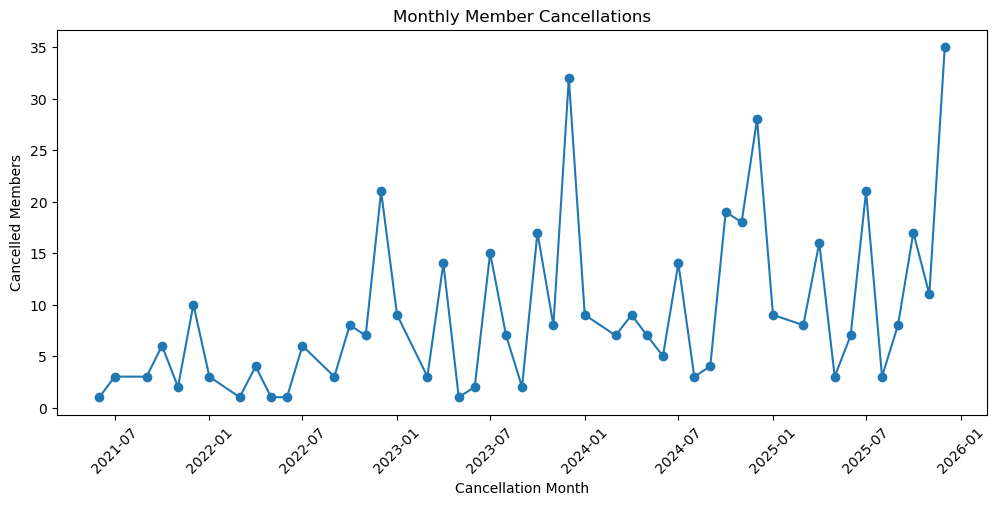

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(
    cancellations_by_month["cancel_month"],
    cancellations_by_month["cancelled_members"],
    marker="o"
)
plt.xlabel("Cancellation Month")
plt.ylabel("Cancelled Members")
plt.title("Monthly Member Cancellations")
plt.xticks(rotation=45)
plt.show()

In [42]:
# Churn by Month of Year

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

cancellations_by_month_name = (
    cancellations
    .groupby("cancel_month_name")
    .agg(cancelled_members=("member_id", "nunique"))
    .reindex(month_order, fill_value=0)
    .reset_index()
)

cancellations_by_month_name

,cancel_month_name,cancelled_members
0,January,30
1,February,0
2,March,19
3,April,43
4,May,12
5,June,16
6,July,59
7,August,13
8,September,20
9,October,67


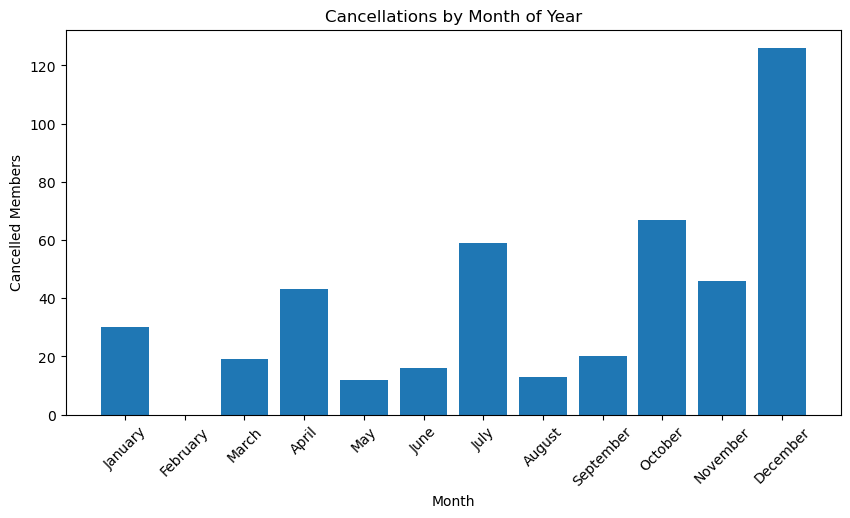

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(
    cancellations_by_month_name["cancel_month_name"],
    cancellations_by_month_name["cancelled_members"]
)
plt.xlabel("Month")
plt.ylabel("Cancelled Members")
plt.title("Cancellations by Month of Year")
plt.xticks(rotation=45)
plt.show()

In [30]:
# Churn by Quarter

cancellations_by_quarter = (
    cancellations
    .groupby("cancel_quarter")
    .agg(cancelled_members=("member_id", "nunique"))
    .reset_index()
    .sort_values("cancel_quarter")
)

cancellations_by_quarter

,cancel_quarter,cancelled_members
0,2021Q2,1
1,2021Q3,6
2,2021Q4,18
3,2022Q1,4
4,2022Q2,6
5,2022Q3,9
6,2022Q4,36
7,2023Q1,12
8,2023Q2,17
9,2023Q3,24


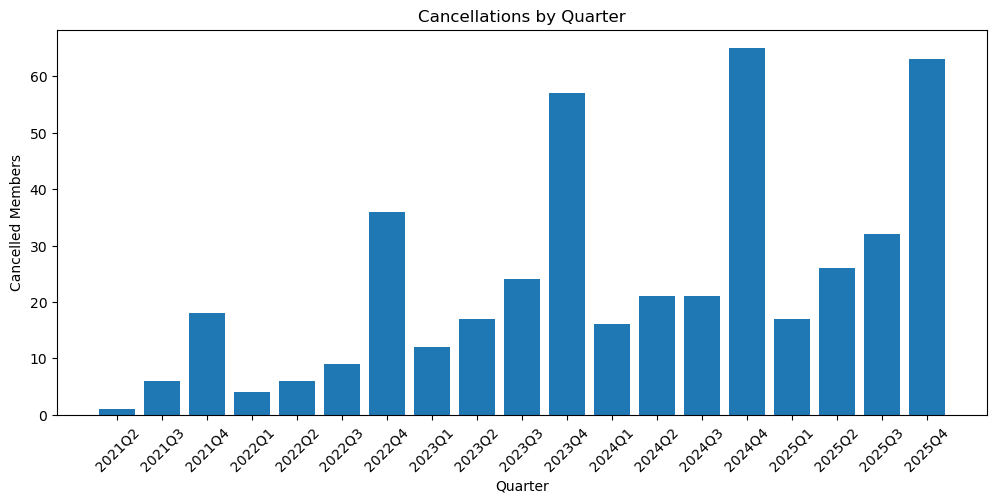

In [31]:
plt.figure(figsize=(12, 5))
plt.bar(
    cancellations_by_quarter["cancel_quarter"],
    cancellations_by_quarter["cancelled_members"]
)
plt.xlabel("Quarter")
plt.ylabel("Cancelled Members")
plt.title("Cancellations by Quarter")
plt.xticks(rotation=45)
plt.show()

In [32]:
# Churn Around Club Releases

raw_club_releases = pd.read_csv(RAW_DIR / "raw_club_releases.csv")
raw_club_releases["release_ship_date"] = pd.to_datetime(
    raw_club_releases["release_ship_date"],
    errors="coerce"
)

In [ ]:
# For each cancelation, find the most recent release before the cancellation.

release_dates = (
    raw_club_releases[
        ["release_id", "release_name", "release_season", "release_ship_date"]
    ]
    .sort_values("release_ship_date")
    .copy()
)

cancellations_sorted = cancellations.sort_values("event_date").copy()

cancellations_with_release = pd.merge_asof(
    cancellations_sorted,
    release_dates,
    left_on="event_date",
    right_on="release_ship_date",
    direction="backward"
)

cancellations_with_release["days_since_last_release"] = (
    cancellations_with_release["event_date"] 
    - cancellations_with_release["release_ship_date"]
).dt.days

cancellations_with_release.head()

,membership_event_id,member_id,event_date,event_type,status,club_tier_at_event,release_id_x,event_source,reason_code,reason_text,created_by,cancel_month,cancel_quarter,cancel_year,cancel_month_num,cancel_month_name,release_id_y,release_name,release_season,release_ship_date,days_since_last_release
0,ME00027264,M002652,2021-06-28,cancellation,cancelled,2 bottle,REL2021SUM,member_portal,temporary_budget,Member requested cancellation after Summer 202...,customer,2021-06-01,2021Q2,2021,6,June,REL2021SUM,Summer 2021,summer,2021-06-17,11
1,ME00037546,M003671,2021-07-03,cancellation,cancelled,12 bottle,REL2021SUM,member_portal,lifestyle_change,Member requested cancellation after Summer 202...,customer,2021-07-01,2021Q3,2021,7,July,REL2021SUM,Summer 2021,summer,2021-06-17,16
2,ME00030005,M002928,2021-07-03,cancellation,cancelled,4 bottle,REL2021SUM,email,temporary_budget,Member requested cancellation after Summer 202...,customer,2021-07-01,2021Q3,2021,7,July,REL2021SUM,Summer 2021,summer,2021-06-17,16
3,ME00042926,M004189,2021-07-30,cancellation,cancelled,4 bottle,REL2021SUM,phone,too_expensive,Member requested cancellation after Summer 202...,customer,2021-07-01,2021Q3,2021,7,July,REL2021SUM,Summer 2021,summer,2021-06-17,43
4,ME00026618,M002584,2021-09-21,cancellation,cancelled,6 bottle,REL2021FAL,phone,moving_or_shipping,Member requested cancellation after Fall 2021 ...,customer,2021-09-01,2021Q3,2021,9,September,REL2021FAL,Fall 2021,fall,2021-09-16,5


In [43]:
raw_club_releases["release_month_num"] = raw_club_releases["release_ship_date"].dt.month
raw_club_releases["release_month_name"] = raw_club_releases["release_ship_date"].dt.month_name()

release_month_counts = (
    raw_club_releases
    .groupby(["release_month_num", "release_month_name"])
    .agg(releases=("release_id", "nunique"))
    .reset_index()
    .sort_values("release_month_num")
)

release_month_counts

,release_month_num,release_month_name,releases
0,3,March,5
1,6,June,5
2,9,September,5
3,11,November,5


### Churn by Month/ Quarter / Club Release Findings

April, July, October, and December stand out, suggesting that cancelations spike after club releases. Winery may need to treat post release dates as critical retention windows. 

In [44]:
# Membership Growth by Join Cohort

# Before analyzing churn by cohort, we need to understand how membership growth changed over time.

# Question:
# When did the winery acquire new club members, and did growth accelerate or slow across the five-year period?

# This matters because churn rates can be misleading if some cohorts are much newer than others. 



# Create Cohort Fields
members_cohort = raw_members.copy()

members_cohort["join_month"] = (
    members_cohort["join_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

members_cohort["join_quarter"] = (
    members_cohort["join_date"]
    .dt.to_period("Q")
    .astype(str)
)

members_cohort["join_year"] = members_cohort["join_date"].dt.year

In [47]:
# New Members by Join Month

new_members_by_month = (
    members_cohort
    .groupby("join_month")
    .agg(new_members=("member_id", "nunique"))
    .reset_index()
    .sort_values("join_month")
)

new_members_by_month.head()

,join_month,new_members
0,2021-01-01,37
1,2021-02-01,48
2,2021-03-01,65
3,2021-04-01,55
4,2021-05-01,70


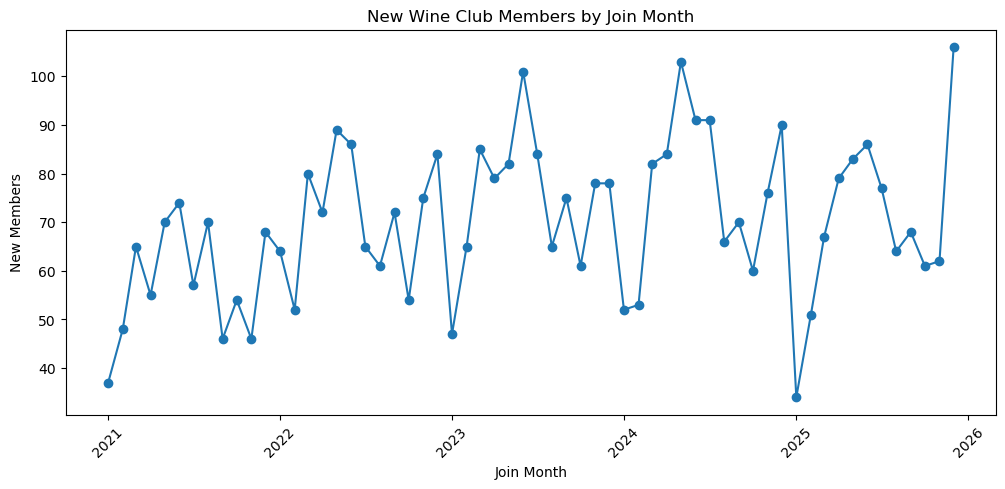

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(
    new_members_by_month["join_month"],
    new_members_by_month["new_members"],
    marker="o"
)
plt.xlabel("Join Month")
plt.ylabel("New Members")
plt.title("New Wine Club Members by Join Month")
plt.xticks(rotation=45)
plt.show()

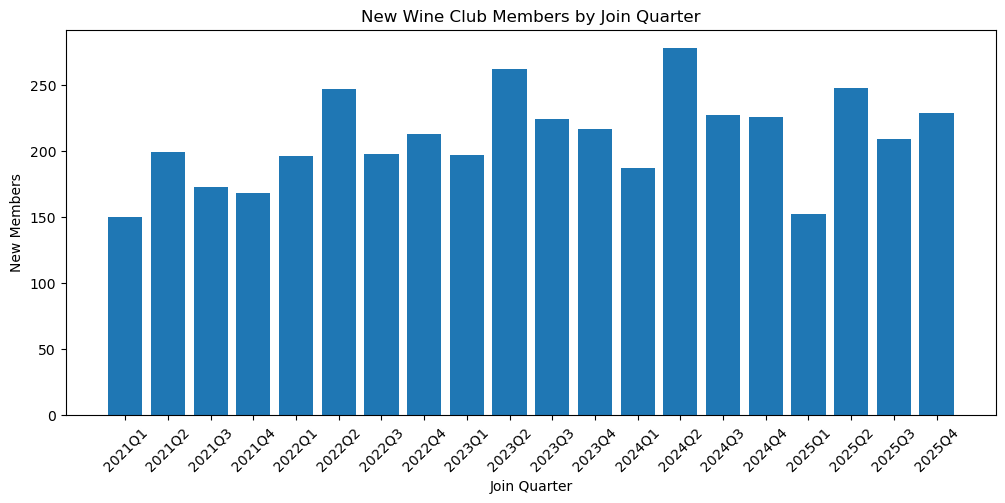

In [49]:
# New members by quarter

new_members_by_quarter = (
    members_cohort
    .groupby("join_quarter")
    .agg(new_members=("member_id", "nunique"))
    .reset_index()
    .sort_values("join_quarter")
)

new_members_by_quarter

# Chart

plt.figure(figsize=(12, 5))
plt.bar(
    new_members_by_quarter["join_quarter"],
    new_members_by_quarter["new_members"]
)
plt.xlabel("Join Quarter")
plt.ylabel("New Members")
plt.title("New Wine Club Members by Join Quarter")
plt.xticks(rotation=45)
plt.show()

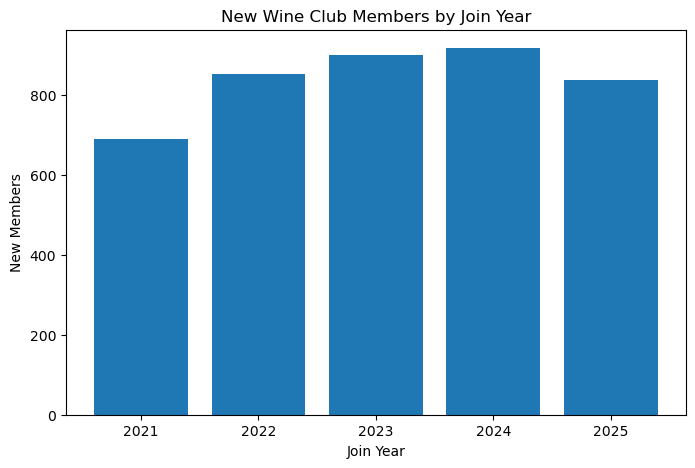

In [50]:
# New members by year

new_members_by_year = (
    members_cohort
    .groupby("join_year")
    .agg(new_members=("member_id", "nunique"))
    .reset_index()
    .sort_values("join_year")
)

new_members_by_year

# Chart

plt.figure(figsize=(8, 5))
plt.bar(
    new_members_by_year["join_year"].astype(str),
    new_members_by_year["new_members"]
)
plt.xlabel("Join Year")
plt.ylabel("New Members")
plt.title("New Wine Club Members by Join Year")
plt.show()

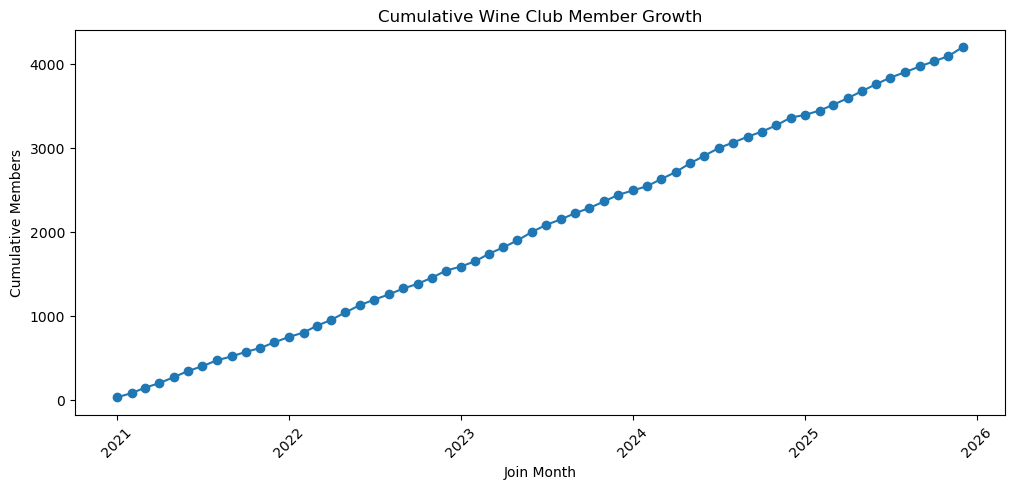

In [51]:
# Cumulative Membership Growth

new_members_by_month["cumulative_members"] = (
    new_members_by_month["new_members"].cumsum()
)

new_members_by_month

# Chart

plt.figure(figsize=(12, 5))
plt.plot(
    new_members_by_month["join_month"],
    new_members_by_month["cumulative_members"],
    marker="o"
)
plt.xlabel("Join Month")
plt.ylabel("Cumulative Members")
plt.title("Cumulative Wine Club Member Growth")
plt.xticks(rotation=45)
plt.show()

### Membership Growth by Join Cohort Findings

At the yearly level, growth appears relatively stable. New member acquisition increased from 2021 through 2024, then declined modestly in 2025.

The quarterly view shows a consistent seasonal pattern: Q2 is the strongest acquisition period in every full year. This likely reflects spring and early-summer tasting room traffic, travel season, and increased winery visitation. Q1 is generally the weakest quarter, especially in 2025.

Overall: The winery appears to have a healthy acquisition engine, especially during Q2. However, acquisition growth alone does not prove the club is healthy.



In [55]:
# Churn by Cohort

# Question:
# Are certain member cohorts retaining worse than others?

churn_by_join_year = (
    members_cohort
    .groupby("join_year")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("member_status", lambda x:(x == 'cancelled').sum())
    )
    .reset_index()
)

churn_by_join_year["active_members"] = (
    churn_by_join_year["members"] - churn_by_join_year["cancelled_members"]
)

churn_by_join_year["churn_rate"] = (
    churn_by_join_year["cancelled_members"] / churn_by_join_year["members"]
)

churn_by_join_year

,join_year,members,cancelled_members,active_members,churn_rate
0,2021,690,106,584,0.153623
1,2022,854,128,726,0.149883
2,2023,900,103,797,0.114444
3,2024,918,83,835,0.090414
4,2025,838,31,807,0.036993


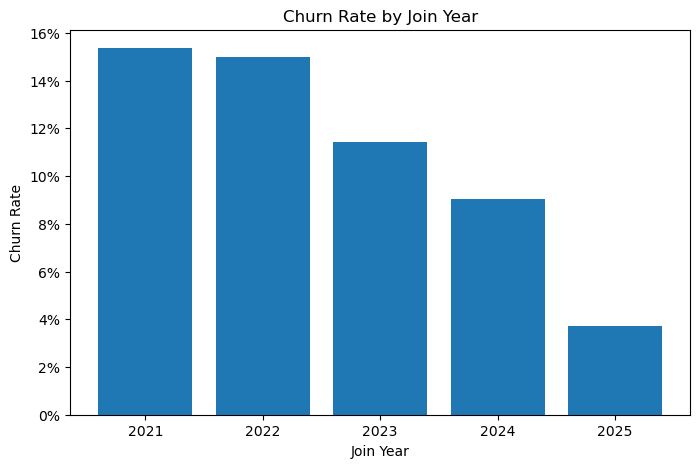

In [56]:
plot_data = churn_by_join_year.sort_values("join_year")

plt.figure(figsize=(8, 5))
plt.bar(
    plot_data["join_year"].astype(str),
    plot_data["churn_rate"]
)
plt.xlabel("Join Year")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Join Year")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.show()

In [57]:
# Quarterly Chohort

churn_by_join_quarter = (
    members_cohort.groupby('join_quarter').agg(
        members = ('member_id', 'nunique'),
        cancelled_members = ('member_status', lambda x: (x == 'cancelled').sum())
    ).reset_index()
)

churn_by_join_quarter["active_members"] = (
    churn_by_join_quarter["members"] - churn_by_join_quarter["cancelled_members"]
)

churn_by_join_quarter["churn_rate"] = (
    churn_by_join_quarter["cancelled_members"] / churn_by_join_quarter["members"]
)

churn_by_join_quarter = churn_by_join_quarter.sort_values("join_quarter")

churn_by_join_quarter

,join_quarter,members,cancelled_members,active_members,churn_rate
0,2021Q1,150,22,128,0.146667
1,2021Q2,199,32,167,0.160804
2,2021Q3,173,27,146,0.156069
3,2021Q4,168,25,143,0.148810
4,2022Q1,196,29,167,0.147959
5,2022Q2,247,30,217,0.121457
6,2022Q3,198,45,153,0.227273
7,2022Q4,213,24,189,0.112676
8,2023Q1,197,20,177,0.101523
9,2023Q2,262,38,224,0.145038


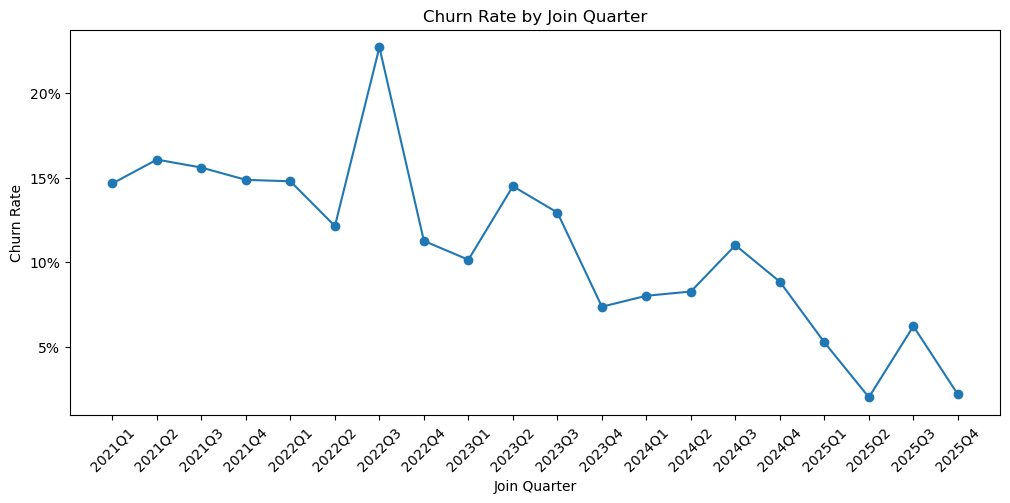

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(
    churn_by_join_quarter["join_quarter"],
    churn_by_join_quarter["churn_rate"],
    marker="o"
)
plt.xlabel("Join Quarter")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Join Quarter")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.show()

### Churn by Join Cohort Findings

Churn generally declines for newer cohorts, which is expected.

Members who joined in 2022 Q3 have the highest observed churn rate at 22.7%. This is meaningfully higher than surrounding cohorts and may indicate that members aquired during that period were lower quality or were exposed to a poor early membership experience.

In [ ]:
# Cancellations by month and year

cancellations = (
    raw_membership_events
    .query("event_type == 'cancellation'")
    .copy()
)

cancellations["cancel_year"] = cancellations["event_date"].dt.year
cancellations["cancel_month_num"] = cancellations["event_date"].dt.month
cancellations["cancel_month_name"] = cancellations["event_date"].dt.month_name()



In [77]:
cancellations_by_year_month = (
    cancellations
    .groupby(["cancel_year", "cancel_month_num", "cancel_month_name"])
    .agg(cancelled_members=("member_id", "nunique"))
    .reset_index()
    .sort_values(["cancel_year", "cancel_month_num"])
)

#cancellations_by_year_month

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

cancellations_year_month_pivot = (
    cancellations_by_year_month
    .pivot_table(
        index="cancel_year",
        columns="cancel_month_name",
        values="cancelled_members",
        fill_value=0
    )
    .reindex(columns=month_order, fill_value=0)
    .reset_index()
)

cancellations_year_month_pivot

cancel_month_name,cancel_year,January,February,March,April,May,June,July,August,September,October,November,December
0,2021,0,0,0,0,0,1,3,0,3,6,2,10
1,2022,3,0,1,4,1,1,6,0,3,8,7,21
2,2023,9,0,3,14,1,2,15,7,2,17,8,32
3,2024,9,0,7,9,7,5,14,3,4,19,18,28
4,2025,9,0,8,16,3,7,21,3,8,17,11,35


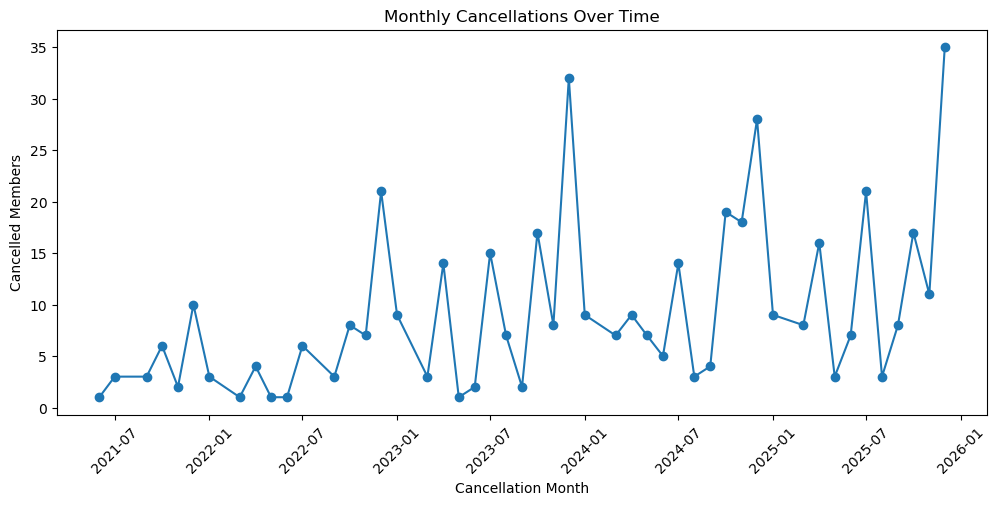

In [78]:
cancellations_by_calendar_month = (
    cancellations
    .assign(cancel_month=cancellations["event_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("cancel_month")
    .agg(cancelled_members=("member_id", "nunique"))
    .reset_index()
    .sort_values("cancel_month")
)

plt.figure(figsize=(12, 5))
plt.plot(
    cancellations_by_calendar_month["cancel_month"],
    cancellations_by_calendar_month["cancelled_members"],
    marker="o"
)
plt.xlabel("Cancellation Month")
plt.ylabel("Cancelled Members")
plt.title("Monthly Cancellations Over Time")
plt.xticks(rotation=45)
plt.show()

### Cancellations by month and year findings

Cancellations increase over time as the member base grows, but the monthly pattern is not random.

December is consistently the highest cancellation month across multiple years, with cancellations rising from 10 in 2021 to 35 in 2025. October is also consistently elevated, and July shows repeated cancellation spikes across several years.

This suggests churn may be connected to the winery operating calendar. December churn may reflect holiday release costs, year-end budget resets, or members reassessing discretionary spending. October and November may be tied to fall or holiday club shipment periods. July may reflect summer shipping concerns, heat-related delivery friction, travel schedules, or lower perceived need for wine shipments during summer.

February has no cancellations across the five-year period. This should not be overinterpreted by itself, but it reinforces that cancellations are not evenly distributed across the year.

### Business Takaway

The winery should treat July, October, November, and December as retention risk windows.

This supports the idea that churn is not only a member-quality problem. It may also be an operating calendar problem.

In [62]:
# Member Tenure Distribution

# Question:
# How long do members typically remain active before cancelling?

# Identify each member's cancellation date from lifecycel events
member_cancellation = (
    raw_membership_events
    .query("event_type == 'cancellation'")
    .groupby('member_id')
    .agg(cancellation_date = ('event_date', 'min'))
    .reset_index()
)

# Build member tenure dataset
member_tenure = (
    raw_members.merge(member_cancellation, on = 'member_id', how ='left')
    .copy()
)

member_tenure['tenure_end_date'] = pd.to_datetime(
    member_tenure['cancellation_date'],
    errors = 'coerce'
)

member_tenure['tenure_end_date'] = (
    member_tenure['cancellation_date'].fillna(analysis_date)
)

member_tenure['tenure_end_date'] = pd.to_datetime(member_tenure['tenure_end_date'])

member_tenure['tenure_days'] = (
    member_tenure['tenure_end_date'] - member_tenure['join_date']
).dt.days

member_tenure['tenure_months'] = member_tenure['tenure_days'] / 30.44
member_tenure['tenure_years'] = member_tenure['tenure_days'] / 365.25

member_tenure['cancelled_flag'] = member_tenure['cancellation_date'].notna().astype(int)

member_tenure.head()

,member_id,customer_account_id,join_date,birth_date,gender,state,zip_code,country,acquisition_source,signup_channel,original_club_tier,current_club_tier,member_status,email_opt_in_flag,sms_opt_in_flag,cancellation_date,tenure_end_date,tenure_days,tenure_months,tenure_years,cancelled_flag
0,M000001,CUST0000001,2022-01-22,1974-07-03,female,CA,90210,US,wine_club_gift,online,4 bottle,2 bottle,active,False,True,NaT,2025-12-31,1439,47.273325,3.939767,0
1,M000002,CUST0000002,2022-09-24,1960-04-08,male,CO,80302,US,website,online,6 bottle,6 bottle,active,True,True,NaT,2025-12-31,1194,39.224704,3.268994,0
2,M000003,CUST0000003,2025-06-10,1979-06-11,male,VA,22201,US,website,online,6 bottle,6 bottle,cancelled,True,False,2025-10-26,2025-10-26,138,4.533509,0.377823,1
3,M000004,CUST0000004,2023-09-08,1965-10-09,female,OH,44113,US,tasting_room,in_person,2 bottle,2 bottle,active,True,True,NaT,2025-12-31,845,27.759527,2.313484,0
4,M000005,CUST0000005,2021-12-21,1959-04-05,male,FL,33139,US,tasting_room,in_person,6 bottle,6 bottle,active,True,False,NaT,2025-12-31,1471,48.324573,4.027379,0


In [66]:
# Check tenure summary

tenure_summary = (
    member_tenure.groupby('cancelled_flag')
    .agg(
        members = ('member_id', 'nunique'),
        avg_tenure_months = ('tenure_months', 'mean'),
        median_tenure_months = ('tenure_months', 'median'),
        min_tenure_months = ('tenure_months', 'min'),
        max_tenure_months = ('tenure_months', 'max')
    ).reset_index()
)

tenure_summary['member_status_group'] = tenure_summary['cancelled_flag'].map({
    0: "Active / Censored",
    1: 'Cancelled'
})

tenure_summary = tenure_summary[
    [
        'member_status_group',
        'members',
        'avg_tenure_months',
        'median_tenure_months',
        'min_tenure_months',
        'max_tenure_months'
    ]
]

tenure_summary

,member_status_group,members,avg_tenure_months,median_tenure_months,min_tenure_months,max_tenure_months
0,Active / Censored,3749,28.074092,27.496715,0.098555,59.921156
1,Cancelled,451,14.980143,11.235217,0.558476,53.022339


In [67]:
# Create tenure bands

tenure_bins = [0, 3, 6, 12, 24, 36, 48, 60, 100]
tenure_labels = [
    '0-3 months',
    '3-6 months',
    '6-12 months',
    '1-2 years',
    '2-3 years',
    '3-4 years',
    '4-5 years',
    '5+ years'
]

member_tenure['tenure_band'] = pd.cut(
    member_tenure['tenure_months'],
    bins = tenure_bins,
    labels = tenure_labels,
    right=False
)

tenure_band_summary = (
    member_tenure.groupby(['tenure_band', 'cancelled_flag'], observed=False)
    .agg(members=('member_id', 'nunique'))
    .reset_index()
)

tenure_band_summary['member_status_group'] = tenure_band_summary['cancelled_flag'].map({
    0 : 'Active/ Censored',
    1 : 'Cancelled'
})

tenure_band_summary

,tenure_band,cancelled_flag,members,member_status_group
0,0-3 months,0,224,Active/ Censored
1,0-3 months,1,49,Cancelled
2,3-6 months,0,192,Active/ Censored
3,3-6 months,1,83,Cancelled
4,6-12 months,0,391,Active/ Censored
5,6-12 months,1,105,Cancelled
6,1-2 years,0,835,Active/ Censored
7,1-2 years,1,114,Cancelled
8,2-3 years,0,797,Active/ Censored
9,2-3 years,1,64,Cancelled


In [ ]:
# Create cleaner pivot table

tenure_band_pivot = (
    tenure_band_summary
    .pivot_table(
        index="tenure_band",
        columns="member_status_group",
        values="members",
        fill_value=0,
        observed=False
    )
    .reset_index()
)

tenure_band_pivot

member_status_group,tenure_band,Active/ Censored,Cancelled
0,0-3 months,224,49
1,3-6 months,192,83
2,6-12 months,391,105
3,1-2 years,835,114
4,2-3 years,797,64
5,3-4 years,726,27
6,4-5 years,584,9
7,5+ years,0,0


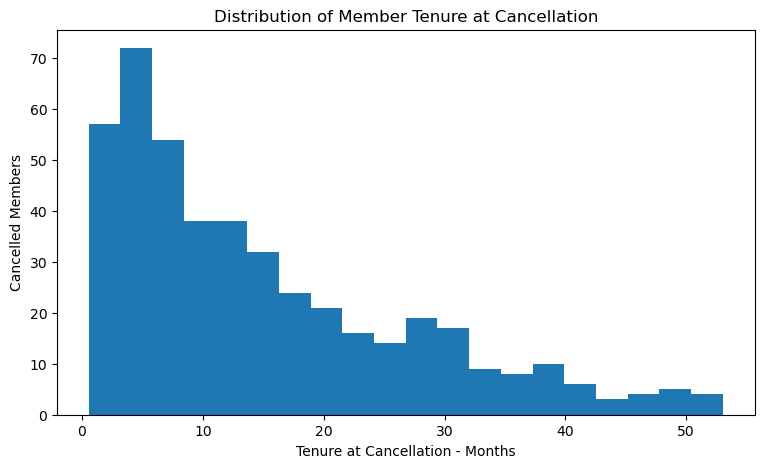

In [69]:
# Chart cancelled member tenure

cancelled_tenure = member_tenure.query("cancelled_flag == 1")

plt.figure(figsize=(9, 5))
plt.hist(cancelled_tenure["tenure_months"], bins=20)
plt.xlabel("Tenure at Cancellation - Months")
plt.ylabel("Cancelled Members")
plt.title("Distribution of Member Tenure at Cancellation")
plt.show()

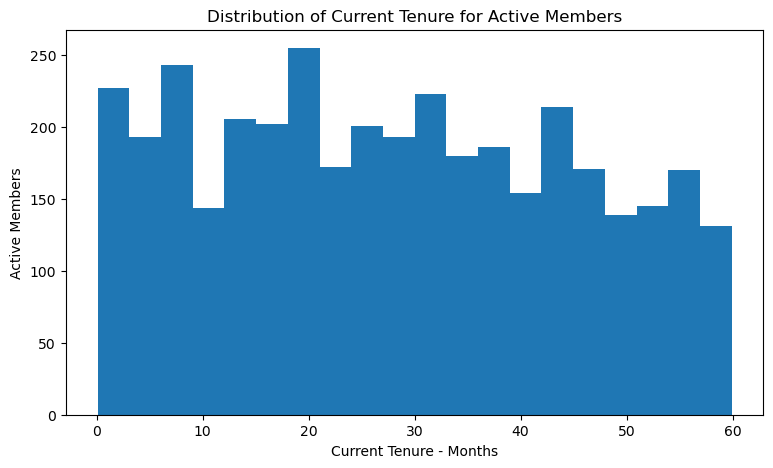

In [ ]:
# Chart active / censored members

active_tenure = member_tenure.query("cancelled_flag == 0")

plt.figure(figsize=(9, 5))
plt.hist(active_tenure["tenure_months"], bins=20)
plt.xlabel("Current Tenure - Months")
plt.ylabel("Active Members")
plt.title("Distribution of Current Tenure for Active Members")
plt.show()

### Member Tenure Distribution Findings

Cancelled members are concentrated early in the membership lifecycle.

The highest number of cancellations occur between 6 and 12 months, followed by 1 to 2 years and 3 to 6 months. This suggests that churn risk is strongest during the first year of membership and remains meaningful into the second year.

This pattern suggests that the winery’s biggest retention challenge is not long-term loyal members suddenly leaving. The bigger issue appears to be converting newer members into committed, multi-year members.

### Business Takeaway
The winery should treat the first 12 months as a the critical retention period. 

Members need stronger onboarding, shipment expectation-setting, release education, and relationship-building before they reach the point of cancellation.


In [80]:
# Revenue by Member Status

# Question:
# How much revenue is associated with aactive members vs cancelled members?

# Revenue by member status
revenue_by_member = (
    raw_orders.query("payment_status == 'paid'").groupby('member_id')
    .agg(
        total_revenue = ('order_amount', 'sum'),
        total_orders = ('order_id', 'nunique'),
        first_order_date = ('order_date', 'min'),
        last_order_date = ('order_date', 'max')
    ).reset_index()
)

revenue_by_member_status = (
    raw_members[['member_id', 'member_status', 'current_club_tier', 'acquisition_source']]
    .merge(revenue_by_member, on='member_id', how='left')
)

revenue_by_member_status['total_revenue'] = revenue_by_member_status['total_revenue'].fillna(0)
revenue_by_member_status['total_orders'] = revenue_by_member_status['total_orders'].fillna(0)

In [83]:
revenue_status_summary = (
    revenue_by_member_status
    .groupby("member_status")
    .agg(
        members=("member_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue_per_member=("total_revenue", "mean"),
        median_revenue_per_member=("total_revenue", "median"),
        avg_orders_per_member=("total_orders", "mean"),
        median_orders_per_member=("total_orders", "median")
    )
    .reset_index()
)

revenue_status_summary["revenue_share"] = (
    revenue_status_summary["total_revenue"] / revenue_status_summary["total_revenue"].sum()
)


revenue_status_display = revenue_status_summary.copy()

revenue_status_display["total_revenue"] = revenue_status_display["total_revenue"].map("${:,.0f}".format)
revenue_status_display["avg_revenue_per_member"] = revenue_status_display["avg_revenue_per_member"].map("${:,.0f}".format)
revenue_status_display["median_revenue_per_member"] = revenue_status_display["median_revenue_per_member"].map("${:,.0f}".format)
revenue_status_display["avg_orders_per_member"] = revenue_status_display["avg_orders_per_member"].round(1)
revenue_status_display["median_orders_per_member"] = revenue_status_display["median_orders_per_member"].round(1)
revenue_status_display["revenue_share"] = (revenue_status_display["revenue_share"] * 100).round(1).astype(str) + "%"

revenue_status_display

,member_status,members,total_revenue,avg_revenue_per_member,median_revenue_per_member,avg_orders_per_member,median_orders_per_member,revenue_share
0,active,3749,"$25,240,052","$6,732","$5,228",12.1,12.0,94.8%
1,cancelled,451,"$1,390,052","$3,082","$1,933",5.7,4.0,5.2%


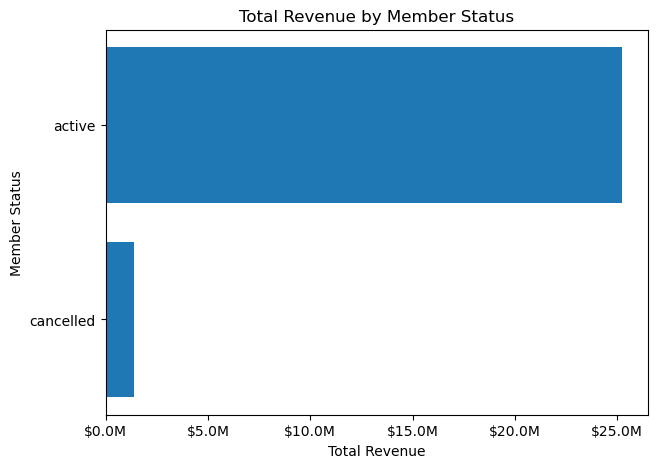

In [84]:
plot_data = revenue_status_summary.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(plot_data["member_status"], plot_data["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Member Status")
plt.title("Total Revenue by Member Status")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
plt.show()

### Revenue by Member Status Findings

Active members account for the majority of historical revenue, generating $25.2M, or 94.8% of total paid order revenue. Cancelled members generated $1.4M before leaving. While cancelled members represent only 10.7% of the member base, they still represent meaningful lost customer value. Their average revenue per member is $3,082, compared with $6,732 for active members.


In [85]:
# Revenue by Club Tier

# Question:
# Which club tiers contribute the most revenue, and where might churn create the biggest financial risk?

revenue_by_tier = (
    revenue_by_member_status
    .groupby("current_club_tier")
    .agg(
        members=("member_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue_per_member=("total_revenue", "mean"),
        median_revenue_per_member=("total_revenue", "median"),
        avg_orders_per_member=("total_orders", "mean"),
        cancelled_members=("member_status", lambda x: (x == "cancelled").sum())
    )
    .assign(
        revenue_share=lambda df: df["total_revenue"] / df["total_revenue"].sum(),
        churn_rate=lambda df: df["cancelled_members"] / df["members"]
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

revenue_by_tier_display = revenue_by_tier.copy()

currency_cols = [
    "total_revenue",
    "avg_revenue_per_member",
    "median_revenue_per_member"
]

for col in currency_cols:
    revenue_by_tier_display[col] = revenue_by_tier_display[col].map("${:,.0f}".format)

revenue_by_tier_display["avg_orders_per_member"] = revenue_by_tier_display["avg_orders_per_member"].round(1)
revenue_by_tier_display["revenue_share"] = (
    revenue_by_tier_display["revenue_share"] * 100
).round(1).astype(str) + "%"

revenue_by_tier_display["churn_rate"] = (
    revenue_by_tier_display["churn_rate"] * 100
).round(1).astype(str) + "%"

revenue_by_tier_display

,current_club_tier,members,total_revenue,avg_revenue_per_member,median_revenue_per_member,avg_orders_per_member,cancelled_members,revenue_share,churn_rate
2,4 bottle,1376,"$8,111,055","$5,895","$5,525",11.1,146,30.5%,10.6%
3,6 bottle,803,"$7,663,597","$9,544","$9,169",13.5,56,28.8%,7.0%
1,2 bottle,1657,"$5,700,321","$3,440","$3,167",10.5,204,21.4%,12.3%
0,12 bottle,364,"$5,155,131","$14,162","$13,809",11.7,45,19.4%,12.4%


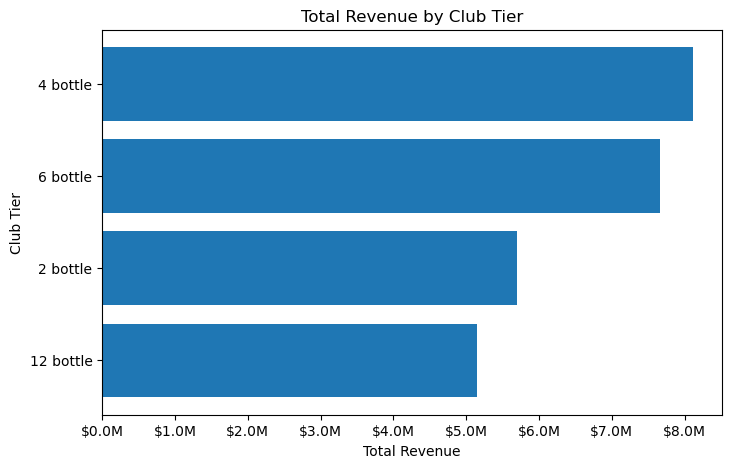

In [86]:
plot_data = revenue_by_tier.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_data["current_club_tier"], plot_data["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Club Tier")
plt.title("Total Revenue by Club Tier")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)
plt.show()

### Revenue by Club Tier Findings

The 4-bottle tier generates the most total revenue at $8.1M, representing 30.5% of paid order revenue. The 6-bottle tier follows closely at $7.7M, or 28.8% of revenue. Together, these two mid-to-premium tiers account for nearly 60% of total revenue.

The 2-bottle tier has the most members but lower revenue per member, generating $5.7M and 21.4% of total revenue. It also has a relatively high churn rate at 12.3%, suggesting this tier may include more casual or lower-commitment members.

The 12-bottle tier has the fewest members but the highest average revenue per member at $14,162. Its churn rate is also the highest at 12.4%, which makes it strategically important despite its smaller size.

The 6-bottle tier stands out as the strongest segment: it has high revenue per member, strong total revenue contribution, and the lowest churn rate at 7.0%.

### Business Takeaway

The winery's retention strategy should be tier-specific.

The 2-bottle tier likely needs scalable retention campaigns focused on onboarding, shipment value, and increasing sales throughout the year. These members are numerous but lower value individually.

The 12-bottle tier needs a more personal retention strategy. Even though this tier is small, each member is highly valuable. Churn in this group should trigger concierge outreach, exclusive allocation messaging, and personalized service.

The 6-bottle tier appears to be the healthiest tier and may represent the winery’s ideal membership sweet spot. The winery should investigate what makes this tier work and consider whether some 4-bottle members can be responsibly upgraded into this tier.


In [87]:
# Revenue by Acquistion Source

# Question:
# Which acquisition sources bring in the most valuable members?

revenue_by_source = (
    revenue_by_member_status
    .groupby("acquisition_source")
    .agg(
        members=("member_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue_per_member=("total_revenue", "mean"),
        median_revenue_per_member=("total_revenue", "median"),
        avg_orders_per_member=("total_orders", "mean"),
        cancelled_members=("member_status", lambda x: (x == "cancelled").sum())
    )
    .assign(
        revenue_share=lambda df: df["total_revenue"] / df["total_revenue"].sum(),
        churn_rate=lambda df: df["cancelled_members"] / df["members"]
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

revenue_by_source_display = revenue_by_source.copy()

currency_cols = [
    "total_revenue",
    "avg_revenue_per_member",
    "median_revenue_per_member"
]

for col in currency_cols:
    revenue_by_source_display[col] = revenue_by_source_display[col].map("${:,.0f}".format)

revenue_by_source_display["avg_orders_per_member"] = (
    revenue_by_source_display["avg_orders_per_member"].round(1)
)

revenue_by_source_display["revenue_share"] = (
    revenue_by_source_display["revenue_share"] * 100
).round(1).astype(str) + "%"

revenue_by_source_display["churn_rate"] = (
    revenue_by_source_display["churn_rate"] * 100
).round(1).astype(str) + "%"

revenue_by_source_display

,acquisition_source,members,total_revenue,avg_revenue_per_member,median_revenue_per_member,avg_orders_per_member,cancelled_members,revenue_share,churn_rate
5,tasting_room,1494,"$10,008,993","$6,699","$5,303",12.3,99,37.6%,6.6%
6,website,1010,"$6,008,233","$5,949","$4,328",10.5,166,22.6%,16.4%
3,referral,430,"$2,857,929","$6,646","$5,411",12.5,22,10.7%,5.1%
1,event,298,"$1,873,675","$6,287","$4,476",10.7,45,7.0%,15.1%
0,concierge,259,"$1,799,837","$6,949","$5,169",12.1,15,6.8%,5.8%
2,paid_social,297,"$1,526,836","$5,141","$3,499",9.0,66,5.7%,22.2%
4,repeat_tasting_room_visit,190,"$1,411,878","$7,431","$5,754",13.5,2,5.3%,1.1%
7,wine_club_gift,222,"$1,142,723","$5,147","$3,780",8.8,36,4.3%,16.2%


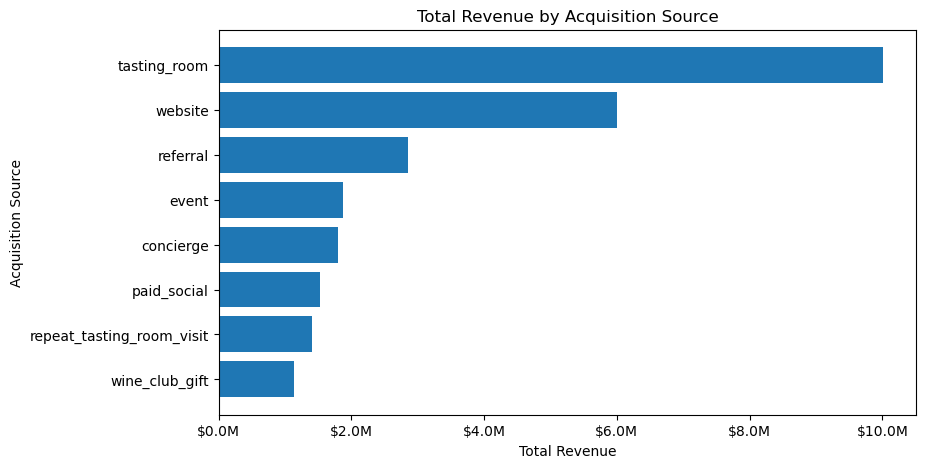

In [88]:
plot_data = revenue_by_source.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_data["acquisition_source"], plot_data["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Acquisition Source")
plt.title("Total Revenue by Acquisition Source")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)
plt.show()

### Revenue by Acquistion Source Takeaway


The tasting room is the largest revenue source, generating $10.0M, or 37.6% of total paid order revenue. It also has a relatively low churn rate at 6.6%, which suggests this channel produces both scale and retention quality.

Website is the second-largest revenue source at $6.0M, or 22.6% of total revenue, but it has a much higher churn rate at 16.4%. This makes website members strategically important: the channel brings in meaningful revenue, but those members appear more vulnerable to cancellation.

Referral, concierge, and repeat tasting room visit members show stronger retention quality. Repeat tasting room visit members have the highest average revenue per member at $7,431 and the lowest churn rate at 1.1%, even though they represent a smaller share of total revenue.

Paid social and wine club gift members have weaker retention and lower average revenue per member. Paid social has the highest churn rate at 22.2%, while wine club gift members churn at 16.2% and have relatively low order frequency.


In [105]:
# Earlly Behavioral Signals: Shipment Skips

# Question:
# Do cancelled members skip shipments more often than active members?

shipment_events = (
    raw_membership_events[
        raw_membership_events["event_type"].isin([
            "shipment_processed",
            "shipment_skipped"
        ])
    ]
    .copy()
)

shipment_skip_summary = (
    shipment_events
    .assign(
        skipped_flag=lambda df: df["event_type"].eq("shipment_skipped").astype(int),
        processed_flag=lambda df: df["event_type"].eq("shipment_processed").astype(int)
    )
    .groupby("member_id")
    .agg(
        total_shipment_events=("membership_event_id", "count"),
        processed_shipments=("processed_flag", "sum"),
        skipped_shipments=("skipped_flag", "sum")
    )
    .reset_index()
)

shipment_skip_summary["skip_rate"] = (
    shipment_skip_summary["skipped_shipments"] 
    / shipment_skip_summary["total_shipment_events"]
)

shipment_skip_summary["ever_skipped_flag"] = (
    shipment_skip_summary["skipped_shipments"] > 0
).astype(int)

shipment_skip_summary["multiple_skips_flag"] = (
    shipment_skip_summary["skipped_shipments"] >= 2
).astype(int)

shipment_skip_summary.head()

,member_id,total_shipment_events,processed_shipments,skipped_shipments,skip_rate,ever_skipped_flag,multiple_skips_flag
0,M000001,16,15,1,0.062500,1,0
1,M000002,13,12,1,0.076923,1,0
2,M000003,1,1,0,0.000000,0,0
3,M000004,10,10,0,0.000000,0,0
4,M000005,16,16,0,0.000000,0,0


In [106]:
# Merge skips back to member status

shipment_skip_member = (
    raw_members[['member_id', 'member_status', 'current_club_tier', 'acquisition_source']]
    .merge(shipment_skip_summary, on = 'member_id', how='left')
)

In [107]:
# Set members with no shipment events to 0

shipment_cols =  [
    'total_shipment_events',
    'processed_shipments',
    'skipped_shipments',
    'skip_rate',
    'ever_skipped_flag',
    'multiple_skips_flag'
]

shipment_skip_member[shipment_cols] = (
    shipment_skip_member[shipment_cols].fillna(0)
)



In [101]:
# Compare Churn by skip behavior

churn_by_skip_flag = (
    shipment_skip_member
    .assign(cancelled_flag=shipment_skip_member["member_status"].eq("cancelled").astype(int))
    .groupby("ever_skipped_flag")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("cancelled_flag", "sum"),
        avg_skipped_shipments=("skipped_shipments", "mean"),
        avg_skip_rate=("skip_rate", "mean")
    )
    .reset_index()
)

churn_by_skip_flag["churn_rate"] = (
    churn_by_skip_flag["cancelled_members"] / churn_by_skip_flag["members"]
)

churn_by_skip_flag["skip_group"] = churn_by_skip_flag["ever_skipped_flag"].map({
    0: "Never Skipped",
    1: "Ever Skipped"
})

churn_by_skip_flag = churn_by_skip_flag[
    [
        "skip_group",
        "members",
        "cancelled_members",
        "churn_rate",
        "avg_skipped_shipments",
        "avg_skip_rate"
    ]
]

churn_by_skip_flag

,skip_group,members,cancelled_members,churn_rate,avg_skipped_shipments,avg_skip_rate
0,Never Skipped,3201,283,0.088410,0.000000,0.0
1,Ever Skipped,999,168,0.168168,1.374374,1.0


In [108]:
# Compare by skip intensity

def assign_skip_band(skipped_shipments):
    if skipped_shipments == 0:
        return "0 skips"
    elif skipped_shipments == 1:
        return "1 skip"
    elif skipped_shipments == 2:
        return "2 skips"
    else:
        return "3+ skips"

shipment_skip_member["skip_band"] = (
    shipment_skip_member["skipped_shipments"]
    .apply(assign_skip_band)
)

skip_band_order = ["0 skips", "1 skip", "2 skips", "3+ skips"]

churn_by_skip_band = (
    shipment_skip_member
    .assign(cancelled_flag=shipment_skip_member["member_status"].eq("cancelled").astype(int))
    .groupby("skip_band")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("cancelled_flag", "sum"),
        avg_skip_rate=("skip_rate", "mean")
    )
    .reindex(skip_band_order)
    .reset_index()
)

churn_by_skip_band["churn_rate"] = (
    churn_by_skip_band["cancelled_members"] / churn_by_skip_band["members"]
)

churn_by_skip_band

,skip_band,members,cancelled_members,avg_skip_rate,churn_rate
0,0 skips,3201,283,0.000000,0.088410
1,1 skip,731,119,0.161460,0.162791
2,2 skips,195,33,0.226736,0.169231
3,3+ skips,73,16,0.328337,0.219178


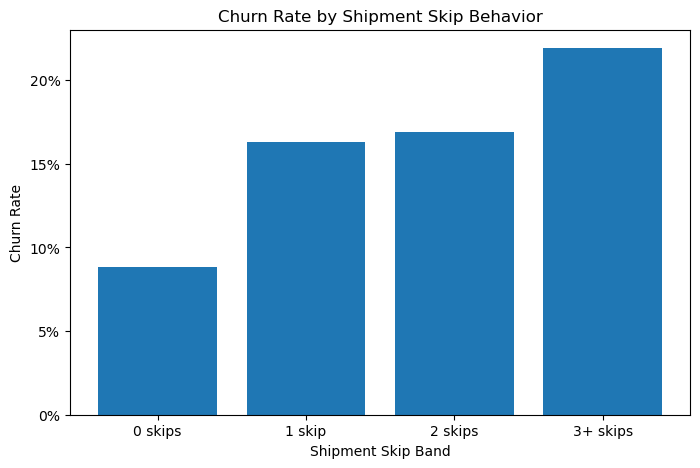

In [103]:
plot_data = churn_by_skip_band.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_data["skip_band"], plot_data["churn_rate"])
plt.xlabel("Shipment Skip Band")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Shipment Skip Behavior")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)
plt.show()

### Shipment Skip Rate Findings

Shipment skips appear to be a meaningful early behavioral signal of churn risk.

Members with no skipped shipments have a churn rate of 8.8%. Members with one skip have a much higher churn rate at 16.3%, and members with two skips churn at 16.9%. Members with three or more skips have the highest churn rate at 21.9%.

### Business Takeaway

The winery should treat repeated shipment skips as a retention warning signal.


In [ ]:
# Early Behavioral Signals: Email Engagement

# Questions: 
# Are members who engage with winery emails less likely to churn?

# Create member-level email engagement

email_engagement_summary = (
    raw_email_events.assign(
        sent_flag = raw_email_events['event_type'].eq('sent').astype(int),
        opened_flag = raw_email_events['event_type'].eq('opened').astype(int),
        clicked_flag = raw_email_events['event_type'].eq('clicked').astype(int),
        unsubscribed_flag = raw_email_events['event_type'].eq('unsubscribed').astype(int),
        bounced_flag = raw_email_events['event_type'].eq('bounced').astype(int)
    )
    .groupby('member_id')
    .agg(
        emails_sent = ('sent_flag', 'sum'),
        emails_opened = ('opened_flag', 'sum'),
        emails_clicked = ('clicked_flag', 'sum'),
        unsubscribes = ('unsubscribed_flag', 'sum'),
        bounces = ('bounced_flag', 'sum')
    )
    .reset_index()
)

email_engagement_summary['open_rate'] = (
    email_engagement_summary['emails_opened'] / email_engagement_summary['emails_sent']
)

email_engagement_summary['click_rate'] = (
    email_engagement_summary['emails_clicked'] / email_engagement_summary['emails_sent']
)

email_engagement_summary['clicked_flag'] = (
    email_engagement_summary['emails_clicked'] > 0 
).astype(int)

email_engagement_summary.head()

,member_id,emails_sent,emails_opened,emails_clicked,unsubscribes,bounces,open_rate,click_rate,clicked_flag
0,M000002,54,24,3,0,0,0.444444,0.055556,1
1,M000003,9,6,0,0,0,0.666667,0.000000,0
2,M000004,39,14,2,0,0,0.358974,0.051282,1
3,M000005,64,41,13,0,0,0.640625,0.203125,1
4,M000007,49,30,0,0,0,0.612245,0.000000,0


In [113]:
# Merge email behavior to members

email_member = (
    raw_members[
        ['member_id', 'member_status', 'current_club_tier', 'acquisition_source']
    ]
    .merge(email_engagement_summary, on='member_id', how='left')
)

email_cols = [
    'emails_sent',
    'emails_opened',
    'emails_clicked',
    'unsubscribes',
    'bounces',
    'open_rate',
    'click_rate',
    'clicked_flag'
]

email_member[email_cols] = email_member[email_cols].fillna(0)

In [114]:
# Churn by click behavior

churn_by_click_flag = (
    email_member
    .assign(cancelled_flag = email_member['member_status'].eq('cancelled').astype(int))
    .groupby('clicked_flag')
    .agg(
        members = ('member_id', 'nunique'),
        cancelled_members = ('cancelled_flag', 'sum'),
        avg_emails_sent = ('emails_sent', 'mean'),
        avg_open_rate = ('open_rate', 'mean'),
        avg_click_rate = ('click_rate', 'mean')
    )
    .reset_index()
)

churn_by_click_flag['churn_rate'] = (
    churn_by_click_flag['cancelled_members'] / churn_by_click_flag['members']
)

churn_by_click_flag['click_group'] = churn_by_click_flag['clicked_flag'].map({
    0: 'No Email Clicks',
    1: 'Clicked At Least Once'
})

churn_by_click_flag = churn_by_click_flag[
    [
    'click_group',
    'members',
    'cancelled_members',
    'churn_rate',
    'avg_open_rate',
    'avg_emails_sent',
    'avg_click_rate'
    ]
]

churn_by_click_flag

,click_group,members,cancelled_members,churn_rate,avg_open_rate,avg_emails_sent,avg_click_rate
0,No Email Clicks,1037,183,0.176471,0.314465,10.326905,0.000000
1,Clicked At Least Once,3163,268,0.084730,0.567190,39.598166,0.111236


In [115]:
# Churn by click intensity

def assign_click_band(clicks):
    if clicks == 0:
        return '0 clicks'
    elif clicks <= 2:
        return '1-2 clicks'
    elif clicks < 5:
        return '3-5 clicks'
    else:
        return '6+ clicks'
    
email_member['click_band'] = (
    email_member['emails_clicked']
    .apply(assign_click_band)
)

click_band_order = ['0 clicks', '1-2 clicks', '3-5 clicks', '6+ clicks']

churn_by_click_band = (
    email_member
    .assign(cancelled_flag=email_member['member_status'].eq('cancelled').astype(int))
    .groupby('click_band')
    .agg(
        members = ('member_id', 'nunique'),
        cancelled_members = ('cancelled_flag', 'sum'),
        avg_click_rate = ('click_rate', 'mean')
    )
    .reindex(click_band_order)
    .reset_index()
)

churn_by_click_band['churn_rate'] = (
    churn_by_click_band['cancelled_members'] / churn_by_click_band['members']
)

churn_by_click_band

,click_band,members,cancelled_members,avg_click_rate,churn_rate
0,0 clicks,1037,183,0.000000,0.176471
1,1-2 clicks,1285,181,0.089703,0.140856
2,3-5 clicks,841,54,0.109058,0.064209
3,6+ clicks,1037,33,0.139684,0.031823


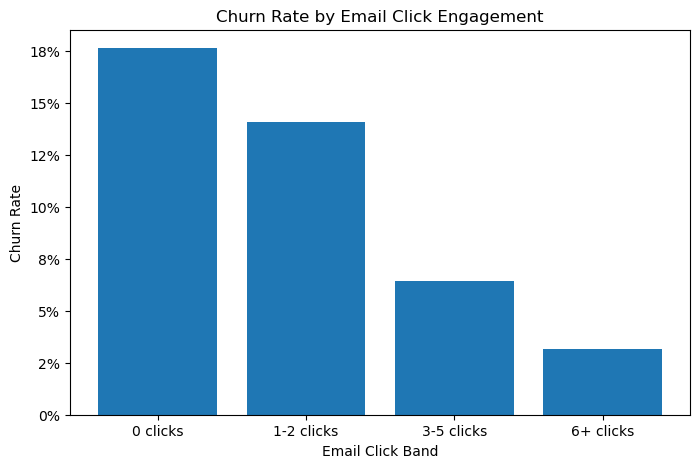

In [116]:
# Chart

plot_data = churn_by_click_band.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_data["click_band"], plot_data["churn_rate"])
plt.xlabel("Email Click Band")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Email Click Engagement")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)
plt.show()

### Email Engagment Findings

Email click engagement is strongly associated with retention.

Members with no email clicks have a churn rate of 17.6%, compared with 8.5% for members who clicked at least once.

The relationship becomes even clearer when engagement is grouped by click volume. Members with zero clicks churn at 17.6%, members with one to two clicks churn at 14.1%, members with three to five clicks churn at 6.4%, and members with six or more clicks churn at only 3.2%.

This suggests that active email engagement may be a protective retention signal. Members who continue clicking on winery communications appear more connected to the winery.

### Business Takaway

The winery should use declining or absent email clicks as an early retention trigger.

This is a good opportunity to test different content styles to improve engagement.

*** This analysis uses lifetime email engagment, so may partly reflect tenure rather than just engagment.

In [117]:
# Early Behavioral Signals: Tasting Room Visits

visit_summary = (
    raw_tasting_room_visits
    .groupby("member_id")
    .agg(
        total_visits=("visit_id", "nunique"),
        total_visit_spend=("spend_amount", "sum"),
        avg_party_size=("party_size", "mean"),
        last_visit_date=("visit_date", "max")
    )
    .reset_index()
)

visit_member = (
    raw_members[
        ["member_id", "member_status", "current_club_tier", "acquisition_source"]
    ]
    .merge(visit_summary, on="member_id", how="left")
)

visit_cols = [
    "total_visits",
    "total_visit_spend",
    "avg_party_size"
]

visit_member[visit_cols] = visit_member[visit_cols].fillna(0)

visit_member["ever_visited_flag"] = (
    visit_member["total_visits"] > 0
).astype(int)

In [118]:
# Compare churn

churn_by_visit_flag = (
    visit_member
    .assign(
        cancelled_flag=visit_member["member_status"].eq("cancelled").astype(int)
    )
    .groupby("ever_visited_flag")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("cancelled_flag", "sum"),
        avg_visits=("total_visits", "mean"),
        avg_visit_spend=("total_visit_spend", "mean")
    )
    .reset_index()
)

churn_by_visit_flag["churn_rate"] = (
    churn_by_visit_flag["cancelled_members"]
    / churn_by_visit_flag["members"]
)

churn_by_visit_flag["visit_group"] = (
    churn_by_visit_flag["ever_visited_flag"].map({
        0: "No Tasting Room Visits",
        1: "Visited Tasting Room"
    })
)

churn_by_visit_flag

,ever_visited_flag,members,cancelled_members,avg_visits,avg_visit_spend,churn_rate,visit_group
0,0,1245,270,0.000000,0.000000,0.216867,No Tasting Room Visits
1,1,2955,181,1.602707,471.963039,0.061252,Visited Tasting Room


In [120]:
# Visit Intensity

def assign_visit_band(visits):
    if visits == 0:
        return "0 visits"
    elif visits == 1:
        return "1 visit"
    elif visits <= 3:
        return "2-3 visits"
    else:
        return "4+ visits"

visit_member["visit_band"] = (
    visit_member["total_visits"].apply(assign_visit_band)
)

visit_band_order = [
    "0 visits",
    "1 visit",
    "2-3 visits",
    "4+ visits"
]

churn_by_visit_band = (
    visit_member
    .assign(
        cancelled_flag=visit_member["member_status"].eq("cancelled").astype(int)
    )
    .groupby("visit_band")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("cancelled_flag", "sum"),
        avg_visit_spend=("total_visit_spend", "mean")
    )
    .reindex(visit_band_order)
    .reset_index()
)

churn_by_visit_band["churn_rate"] = (
    churn_by_visit_band["cancelled_members"]
    / churn_by_visit_band["members"]
)

churn_by_visit_band

,visit_band,members,cancelled_members,avg_visit_spend,churn_rate
0,0 visits,1245,270,0.000000,0.216867
1,1 visit,1641,143,280.575424,0.087142
2,2-3 visits,1255,38,688.393936,0.030279
3,4+ visits,59,0,1191.391864,0.000000


In [122]:
# Early Behaviorall Signals: Event Attendance

event_summary = (
    raw_event_attendance
    .groupby("member_id")
    .agg(
        events_registered=("event_attendance_id", "nunique"),
        events_attended=("attended_flag", "sum"),
        total_ticket_value=("ticket_value", "sum"),
        total_event_purchase_amount=("purchase_at_event_amount", "sum"),
        last_event_date=("event_date", "max")
    )
    .reset_index()
)

event_member = (
    raw_members[
        ["member_id", "member_status", "current_club_tier", "acquisition_source"]
    ]
    .merge(event_summary, on="member_id", how="left")
)

event_cols = [
    "events_registered",
    "events_attended",
    "total_ticket_value",
    "total_event_purchase_amount"
]

event_member[event_cols] = event_member[event_cols].fillna(0)

event_member["ever_attended_flag"] = (
    event_member["events_attended"] > 0
).astype(int)

In [123]:
# Compare Churn

churn_by_event_flag = (
    event_member
    .assign(
        cancelled_flag=event_member["member_status"].eq("cancelled").astype(int)
    )
    .groupby("ever_attended_flag")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("cancelled_flag", "sum"),
        avg_events_attended=("events_attended", "mean"),
        avg_event_purchase_amount=("total_event_purchase_amount", "mean")
    )
    .reset_index()
)

churn_by_event_flag["churn_rate"] = (
    churn_by_event_flag["cancelled_members"]
    / churn_by_event_flag["members"]
)

churn_by_event_flag["event_group"] = (
    churn_by_event_flag["ever_attended_flag"].map({
        0: "No Event Attendance",
        1: "Attended Winery Event"
    })
)

churn_by_event_flag

,ever_attended_flag,members,cancelled_members,avg_events_attended,avg_event_purchase_amount,churn_rate,event_group
0,0,1415,314,0.000000,0.000000,0.221908,No Event Attendance
1,1,2785,137,3.040575,368.005095,0.049192,Attended Winery Event


In [124]:
# Event Intensity

def assign_event_band(events):
    if events == 0:
        return "0 events"
    elif events == 1:
        return "1 event"
    elif events <= 3:
        return "2-3 events"
    else:
        return "4+ events"

event_member["event_band"] = (
    event_member["events_attended"].apply(assign_event_band)
)

event_band_order = [
    "0 events",
    "1 event",
    "2-3 events",
    "4+ events"
]

churn_by_event_band = (
    event_member
    .assign(
        cancelled_flag=event_member["member_status"].eq("cancelled").astype(int)
    )
    .groupby("event_band")
    .agg(
        members=("member_id", "nunique"),
        cancelled_members=("cancelled_flag", "sum"),
        avg_event_purchase_amount=("total_event_purchase_amount", "mean")
    )
    .reindex(event_band_order)
    .reset_index()
)

churn_by_event_band["churn_rate"] = (
    churn_by_event_band["cancelled_members"]
    / churn_by_event_band["members"]
)

churn_by_event_band

,event_band,members,cancelled_members,avg_event_purchase_amount,churn_rate
0,0 events,1415,314,0.000000,0.221908
1,1 event,919,80,101.827236,0.087051
2,2-3 events,1003,41,289.807587,0.040877
3,4+ events,863,16,742.338297,0.018540


### Tasting Room Visit Findings

Members with no tasting room visits have a churn rate of 21.7%, compared with 6.1% for members who visited at least once.

The relationship strengthens with visit frequency. Members with one visit churn at 8.7%, members with two to three visits churn at 3.0%, and no cancellations occurred among the 59 members with four or more visits.

This suggests tasting room engagement is closely associated with retention. Visits likely strengthen product familiarity, staff relationships, and emotional connection to the winery.


### Event Attendance Findings

Members with no event attendance have a churn rate of 22.2%, compared with 4.9% among members who attended at least one event.

Churn declines as attendance increases:
 - 1 event: 8.7%
 - 2–3 events: 4.1%
 - 4+ events: 1.9%

Event attendance appears to represent meaningful relationship depth. Members who invest time in winery experiences are much less likely to cancel.


### Business Takeaway

The winery should treat tasting room visits and event attendance as retention tools, not just revenue channels.

Members showing declining engagement could be targeted with tasting invitations, pickup experiences, virtual tastings, or exclusive events. High-value out-of-state members may need digital or regional alternatives that recreate the relationship-building effect of visiting the winery.

## EDA Executive Summary

The exploratory analysis shows that churn is not evenly distributed across the wine club.

The highest-risk members are more likely to come from paid social, website, gift, and event acquisition channels, join online, live outside California, skip shipments, avoid clicking emails, and have little or no tasting room or event engagement.

The 6-bottle tier has the strongest retention at 7.0%, while the 2-bottle and 12-bottle tiers both churn at roughly 12%. This suggests retention pressure exists at both the casual and collector ends of the membership spectrum.

Acquisition context is one of the clearest retention signals. Paid social members churn at 22.2%, compared with 6.6% for tasting room members, 5.1% for referrals, and 1.1% for repeat tasting room visitors.

Behavioral engagement is also strongly associated with retention. Members with three or more shipment skips churn at 21.9%. Members with no email clicks churn at 17.6%, compared with 3.2% among members with six or more clicks.

Relationship-building activity appears especially important. Members with no tasting room visits churn at 21.7%, compared with 6.1% among visitors. Members with no event attendance churn at 22.2%, compared with 4.9% among attendees.

Churn is concentrated earlier in the member lifecycle and appears elevated around July, October, November, and December. This suggests that the first year, summer shipping periods, and holiday release windows may be critical retention moments.

From a revenue perspective, the 12-bottle tier deserves special attention. It has the highest revenue per member at more than $14,000, but also the highest churn rate. The 6-bottle tier appears to be the healthiest segment, combining high revenue per member with the lowest churn rate.

Overall, the EDA suggests that wine club churn is driven by a combination of member intent, signup context, shipment friction, declining engagement, and weak relationship depth.



#### Key Questions for Survival Analysis

The EDA raises several questions that descriptive analysis cannot answer on its own:

1. At what point in the membership lifecycle does churn risk increase most sharply?

2. Do acquisition source and signup channel still predict churn after controlling for tenure?

3. Does the 6-bottle tier retain better after accounting for member age, geography, and acquisition source?

4. Are shipment skips independently associated with higher churn risk?

5. Do email clicks, tasting room visits, and event attendance remain protective after controlling for tenure?

6. Are out-of-state members more likely to churn because of geography itself, or because they have fewer relationship touchpoints?

7. How do retention curves differ across club tiers, acquisition sources, and engagement groups?

The next phase will use Kaplan-Meier survival analysis to estimate how retention changes over time and compare survival curves across key member segments.